In [1]:
import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
RAW_DIR = '../data/raw/test'
PRED_DIR = '../data/predictions'

In [3]:
chip_id  = '0a0a36'

In [4]:
with rasterio.open(f'{RAW_DIR}/{chip_id}/{chip_id}.tif') as src:
    rgba = src.read([1, 2, 3, 4])

In [5]:
with rasterio.open(f'{PRED_DIR}/{chip_id}_pred.tif') as src:
    mask = src.read(1)

In [6]:
image = np.moveaxis(rgba[:3], 0, -1) / 255.0   # (H, W, 3)

In [7]:
mask.sum()

np.uint64(219367)

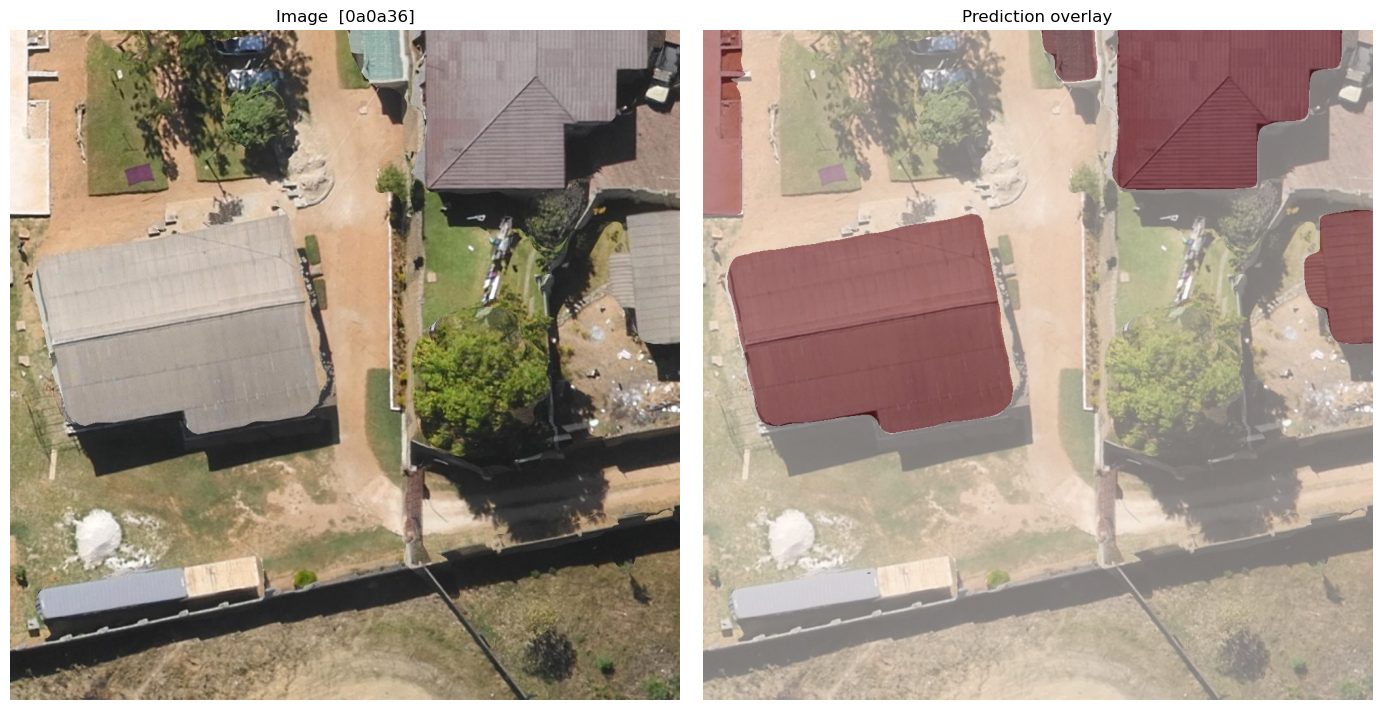

In [8]:
# Cell 3 — plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(image)
axes[0].set_title(f'Image  [{chip_id}]')
axes[0].axis('off')

axes[1].imshow(image)
axes[1].imshow(mask, alpha=0.45, cmap='Reds', vmin=0, vmax=1)
axes[1].set_title('Prediction overlay')
axes[1].axis('off')

plt.tight_layout()
fig.savefig(f'../results/{chip_id}_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

Checking some random chips:

In [9]:
chip_ids = [p.stem.replace('_pred', '') for p in sorted(Path(PRED_DIR).glob('*_pred.tif'))]
sample   = random.sample(chip_ids, 3 * 3)

In [10]:
sample

['f0c36e',
 '782216',
 '0ab84f',
 '0f5810',
 '0f2b62',
 '7a80f1',
 '313fc3',
 '8a09e8',
 'f334ba']

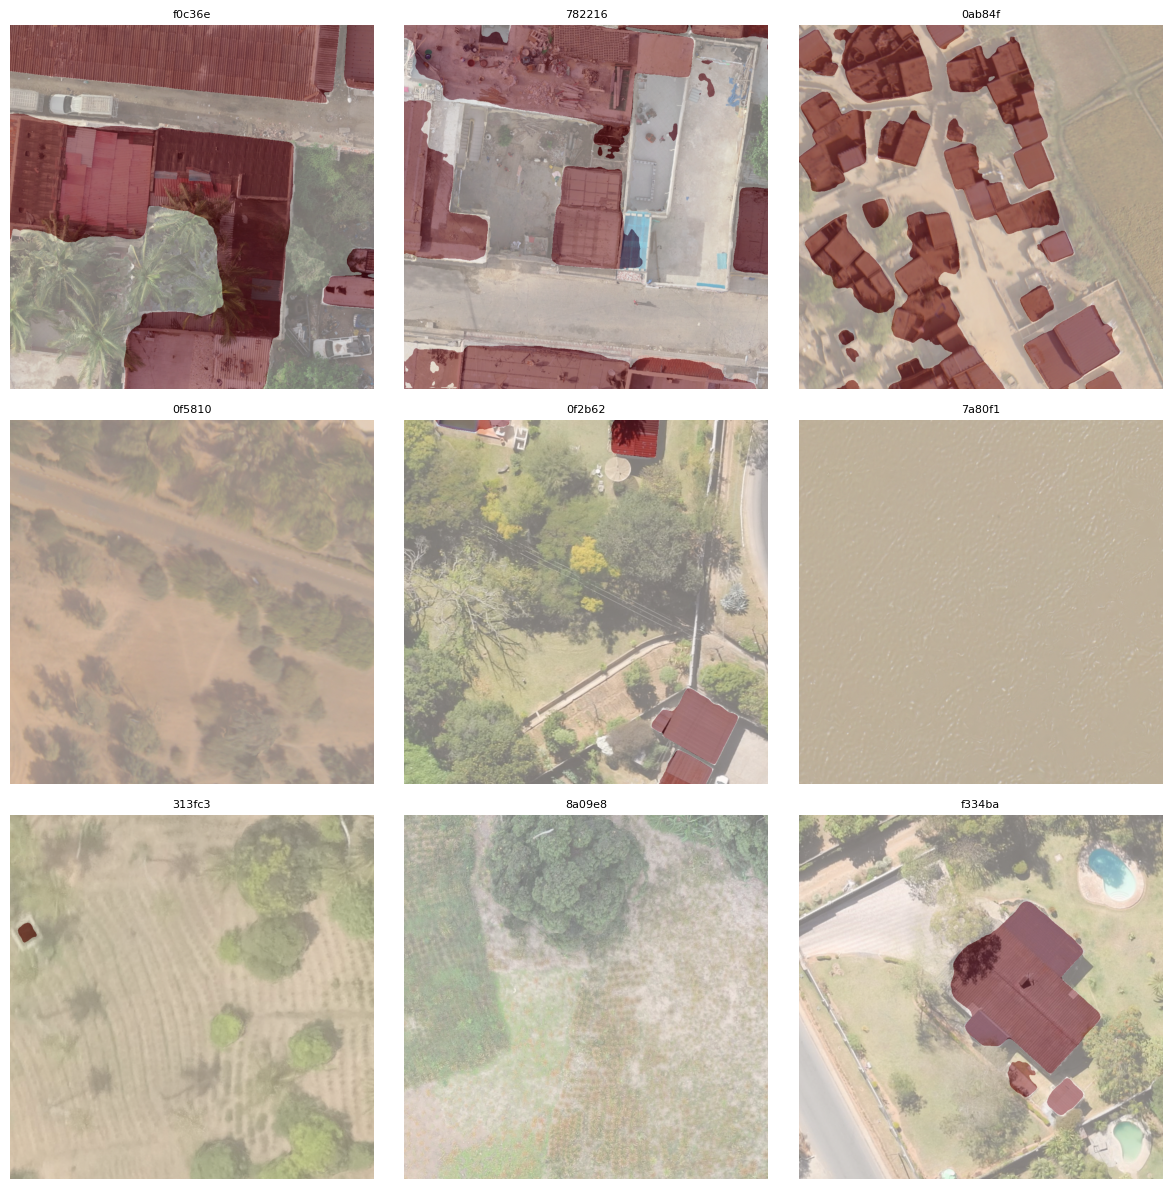

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(3 * 4, 3 * 4))

for ax, chip_id in zip(axes.flat, sample):
    with rasterio.open(f'{RAW_DIR}/{chip_id}/{chip_id}.tif') as src:
        rgba = src.read([1, 2, 3, 4])
    with rasterio.open(f'{PRED_DIR}/{chip_id}_pred.tif') as src:
        mask = src.read(1)

    image = np.moveaxis(rgba[:3], 0, -1) / 255.0
    ax.imshow(image)
    ax.imshow(mask, alpha=0.45, cmap='Reds', vmin=0, vmax=1)
    ax.set_title(chip_id, fontsize=8)
    ax.axis('off')

plt.tight_layout()
fig.savefig(f'../results/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()